In [ ]:
# Install meridian: from PyPI @ latest release
!pip install --upgrade google-meridian[colab,and-cuda,schema]

# Install meridian: from PyPI @ specific version
# !pip install google-meridian[colab,and-cuda,schema]==1.3.1

# Install meridian: from GitHub @HEAD
# !pip install --upgrade "google-meridian[colab,and-cuda,schema] @ git+https://github.com/google/meridian.git@main"

In [ ]:

import IPython
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import pandas as pd
import tensorflow as tf
import tensorflow_probability as tfp
from psutil import virtual_memory

from meridian import constants
from meridian.analysis import analyzer, optimizer, summarizer, visualizer
from meridian.analysis.review import reviewer
from meridian.data import data_frame_input_data_builder
from meridian.model import model, prior_distribution, spec
from meridian.model.eda import meridian_eda
from meridian.schema.serde import meridian_serde

ram_gb = virtual_memory().total / 1e9
print(f"RAM: {ram_gb:.1f} GB")
print(f"GPUs: {len(tf.config.experimental.list_physical_devices('GPU'))}")



RAM: 13.6 GB
GPUs: 0


In [ ]:
from google.colab import drive
drive_mount = "/content/drive"
drive.mount(drive_mount, force_remount=True)
meridian_root = f"{drive_mount}/MyDrive/"



Mounted at /content/drive


CONFIG — edit this section for different datasets


In [ ]:
TIME_COL = "time"
GEO_COL = "geo"
CHANNELS = ["Channel0", "Channel1", "Channel2", "Channel3", "Channel4"]
IMPRESSION_SUFFIX = "_impression"
SPEND_SUFFIX = "_spend"
KPI_COL = "conversions"
REV_PER_KPI_COL = "revenue_per_conversion"
NON_MEDIA_COLS = ["Promo"]
ORGANIC_COLS = ["Organic_channel0_impression"]
ORGANIC_NAMES = ["Organic_channel0"]
DROP_COLS = ["competitor_sales_control", "sentiment_score_control", "population"]

DATA_URL = (
    "https://raw.githubusercontent.com/google/meridian/"
    "refs/heads/main/meridian/data/simulated_data/csv/geo_all_channels.csv"
)

# Forecast settings
CORRESPONDING_QUARTER = ("2023-01-16", "2023-04-15")  # baseline for naive forecast
N_FUTURE_WEEKS = 13

# Model settings
ROI_MU = 0.2
ROI_SIGMA = 0.9
N_CHAINS = 5
N_ADAPT = 1500
N_BURNIN = 500
N_KEEP = 500
SEED = 42
N_PRIOR_SAMPLES = 500



STEP 1: LOAD DATA



In [ ]:
df = pd.read_csv(DATA_URL, index_col=0)
print(f"Raw data: {df.shape[0]} rows, {df[GEO_COL].nunique()} geos, {df[TIME_COL].nunique()} weeks")



Raw data: 6240 rows, 40 geos, 156 weeks


STEP 2: AGGREGATE TO NATIONAL LEVEL


In [ ]:
media_cols = [f"{ch}{IMPRESSION_SUFFIX}" for ch in CHANNELS]
spend_cols = [f"{ch}{SPEND_SUFFIX}" for ch in CHANNELS]

raw_df = df.copy()
raw_df["revenue"] = raw_df[KPI_COL] * raw_df[REV_PER_KPI_COL]

agg_dict = {col: "sum" for col in media_cols + spend_cols + ORGANIC_COLS + [KPI_COL, "revenue"]}
for col in NON_MEDIA_COLS:
    agg_dict[col] = "mean"

national_df = raw_df.groupby(TIME_COL).agg(agg_dict).reset_index()
national_df[REV_PER_KPI_COL] = national_df["revenue"] / national_df[KPI_COL]
national_df.drop(columns=["revenue"], inplace=True)

print(f"National dataset: {national_df.shape[0]} weeks")
national_df.head()



National dataset: 156 weeks


,time,Channel0_impression,Channel1_impression,Channel2_impression,Channel3_impression,Channel4_impression,Channel0_spend,Channel1_spend,Channel2_spend,Channel3_spend,Channel4_spend,Organic_channel0_impression,conversions,Promo,revenue_per_conversion
0,2021-01-25,44340630,10537596,6501889,66738506,53026011,325137.56830,101595.404270,48315.04518,520082.5242,413173.984050,24028870,386300926.3,0.234740,0.020015
1,2021-02-01,47391940,30857600,7966320,79000018,27592214,347511.96809,297505.263890,59197.12148,615634.5403,214996.093200,29188267,355303931.3,0.145423,0.019996
2,2021-02-08,28960185,23144749,4637739,68442555,20057461,212357.01945,223143.885196,34462.68770,533361.9165,156285.964472,12051369,438308889.8,0.537338,0.019992
3,2021-02-15,38126016,10667077,3029637,70601091,37246623,279567.52290,102843.758830,22513.00335,550183.0380,290222.395240,9595212,418612413.7,0.367233,0.019979
4,2021-02-22,46890794,17925961,10486840,81842660,56259530,343837.20920,172828.342330,77926.91530,637786.8024,438369.280950,9288846,355785298.0,0.429602,0.019983


STEP 3: BUILD INPUTDATA


In [ ]:
builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
    kpi_type="non_revenue",
    default_kpi_column=KPI_COL,
    default_revenue_per_kpi_column=REV_PER_KPI_COL,
)

builder = (
    builder
    .with_kpi(national_df)
    .with_revenue_per_kpi(national_df)
    .with_media(
        national_df,
        media_cols=media_cols,
        media_spend_cols=spend_cols,
        media_channels=CHANNELS,
    )
    .with_non_media_treatments(
        national_df,
        non_media_treatment_cols=NON_MEDIA_COLS,
    )
    .with_organic_media(
        national_df,
        organic_media_cols=ORGANIC_COLS,
        organic_media_channels=ORGANIC_NAMES,
    )
)

data = builder.build()
print("InputData built successfully.")

InputData built successfully.


STEP 4: CONFIGURE & FIT MODEL


In [ ]:
prior = prior_distribution.PriorDistribution(
    roi_m=tfp.distributions.LogNormal(ROI_MU, ROI_SIGMA, name=constants.ROI_M)
)
model_spec = spec.ModelSpec(prior=prior)
mmm = model.Meridian(input_data=data, model_spec=model_spec)
mmm.sample_prior(N_PRIOR_SAMPLES)



/usr/local/lib/python3.13/dist-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/model/prior_distribution.py:1391: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/model/prior_distribution.py:1391: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/model/prior_distribution.py:1391: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.13/dist-p

In [ ]:
mmm.sample_posterior(
    n_chains=N_CHAINS, n_adapt=N_ADAPT, n_burnin=N_BURNIN, n_keep=N_KEEP, seed=SEED
)



/usr/local/lib/python3.13/dist-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(


STEP 5: DIAGNOSTICS



In [ ]:
model_diagnostics = visualizer.ModelDiagnostics(mmm)
model_diagnostics.plot_rhat_boxplot()

model_fit = visualizer.ModelFit(mmm)
model_fit.plot_model_fit()

health_summary = reviewer.ModelReviewer(mmm).run()
health_summary.output_model_health_card(filename="health_card.html", filepath=meridian_root)



/usr/local/lib/python3.13/dist-packages/meridian/analysis/analyzer.py:103: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/tmp/ipykernel_45830/3604833475.py:7: DeprecationWarning: The `meridian` argument is deprecated. Please use `model_context` and `inference_data` instead.
  health_summary = reviewer.ModelReviewer(mmm).run()
/usr/local/lib/python3.13/dist-packages/meridian/analysis/analyzer.py:103: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(


STEP 6: SUMMARY REPORT



In [ ]:
mmm_summarizer = summarizer.Summarizer(mmm)
start_date = national_df[TIME_COL].min()
end_date = national_df[TIME_COL].max()
mmm_summarizer.output_model_results_summary(
    "summary_output.html", meridian_root, start_date, end_date
)
IPython.display.HTML(filename=f"{meridian_root}/summary_output.html")



/usr/local/lib/python3.13/dist-packages/meridian/analysis/analyzer.py:103: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/analysis/analyzer.py:103: UserWarning: The `aggregate_geos` argument is ignored in the national model. It will be reset to `True`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/numpy/lib/_function_base_impl.py:4620: RuntimeWarning: invalid value encountered in subtract
  diff_b_a = subtract(b, a)
/usr/local/lib/python3.13/dist-packages/meridian/analysis/analyzer.py:2401: UserWarning: Effectiveness is not reported because it does not have a clear interpretation by time period.
  warnings.warn(


Dataset,R-squared,MAPE,wMAPE
All Data,0.06,5%,5%


## PHASE 1: TREND ESTIMATION



In [ ]:

def compute_trend_multipliers(
    df,
    channels,
    kpi_col,
    rev_per_kpi_col,
    time_col="time",
    non_media_cols=None,
    organic_cols=None,
    impression_suffix="_impression",
    spend_suffix="_spend",
):

#Compute quarterly growth rates for each forecasting input.
#    Returns trend_multipliers dict and quarterly_df.

    if non_media_cols is None:
        non_media_cols = []
    if organic_cols is None:
        organic_cols = []

    df = df.copy()
    df["time_dt"] = pd.to_datetime(df[time_col])
    df["quarter"] = df["time_dt"].dt.to_period("Q")

    quarterly = {}
    for q, group in df.groupby("quarter"):
        q_data = {"quarter": str(q)}

        for ch in channels:
            imp_col = f"{ch}{impression_suffix}"
            spd_col = f"{ch}{spend_suffix}"
            q_data[f"{ch}_spend"] = group[spd_col].sum()
            total_imp = group[imp_col].sum()
            total_spend = group[spd_col].sum()
            q_data[f"{ch}_cpi"] = total_spend / total_imp if total_imp > 0 else 0

        for col in non_media_cols:
            q_data[col] = group[col].mean()

        for col in organic_cols:
            q_data[col] = group[col].mean()

        total_kpi = group[kpi_col].sum()
        total_rev = (group[kpi_col] * group[rev_per_kpi_col]).sum()
        q_data["rev_per_kpi"] = total_rev / total_kpi if total_kpi > 0 else 0

        quarterly[str(q)] = q_data

    quarterly_df = pd.DataFrame(quarterly.values())

    # Drop partial last quarter
    week_counts = df.groupby("quarter").size()
    typical_weeks = int(week_counts.iloc[:-1].median())
    last_q_weeks = week_counts.iloc[-1]
    if last_q_weeks < typical_weeks * 0.75:
        quarterly_df = quarterly_df.iloc[:-1]
        print(f"Dropped partial last quarter ({last_q_weeks} weeks, typical is {typical_weeks})")

    variables_to_track = (
        [f"{ch}_spend" for ch in channels]
        + [f"{ch}_cpi" for ch in channels]
        + non_media_cols
        + organic_cols
        + ["rev_per_kpi"]
    )

    growth_rates = {}
    for var in variables_to_track:
        rates = []
        values = quarterly_df[var].values
        for i in range(1, len(values)):
            if values[i - 1] > 0:
                rate = values[i] / values[i - 1]
                rates.append(rate)
        growth_rates[var] = rates

    trend_multipliers = {}
    for var, rates in growth_rates.items():
        trend_multipliers[var] = np.mean(rates) if len(rates) > 0 else 1.0

    # Print summary
    print("=== Trend Multipliers (per quarter) ===\n")
    for ch in channels:
        cpi_pct = (trend_multipliers[f"{ch}_cpi"] - 1) * 100
        spend_pct = (trend_multipliers[f"{ch}_spend"] - 1) * 100
        print(f"{ch}:")
        print(f"  CPI: {'growing' if cpi_pct > 0 else 'declining'} at {abs(cpi_pct):.1f}%/quarter")
        print(f"  Spend: {'growing' if spend_pct > 0 else 'declining'} at {abs(spend_pct):.1f}%/quarter")
    print()
    for var_name, var_key in [("Revenue per KPI", "rev_per_kpi")] + [(c, c) for c in non_media_cols + organic_cols]:
        pct = (trend_multipliers[var_key] - 1) * 100
        print(f"{var_name}: {'growing' if pct > 0 else 'declining'} at {abs(pct):.1f}%/quarter")

    return trend_multipliers, quarterly_df


trend_multipliers, quarterly_df = compute_trend_multipliers(
    national_df,
    channels=CHANNELS,
    kpi_col=KPI_COL,
    rev_per_kpi_col=REV_PER_KPI_COL,
    time_col=TIME_COL,
    non_media_cols=NON_MEDIA_COLS,
    organic_cols=ORGANIC_COLS,
    impression_suffix=IMPRESSION_SUFFIX,
    spend_suffix=SPEND_SUFFIX,
)



Dropped partial last quarter (3 weeks, typical is 13)
=== Trend Multipliers (per quarter) ===

Channel0:
  CPI: growing at 0.0%/quarter
  Spend: growing at 5.7%/quarter
Channel1:
  CPI: declining at 0.0%/quarter
  Spend: growing at 9.0%/quarter
Channel2:
  CPI: growing at 0.0%/quarter
  Spend: growing at 30.5%/quarter
Channel3:
  CPI: growing at 0.0%/quarter
  Spend: growing at 7.2%/quarter
Channel4:
  CPI: declining at 0.0%/quarter
  Spend: growing at 6.6%/quarter

Revenue per KPI: growing at 0.0%/quarter
Promo: growing at 13.4%/quarter
Organic_channel0_impression: growing at 10.2%/quarter



## FORECAST CONFIG (with overrides)



In [ ]:

def build_forecast_config(
    df,
    trend_multipliers,
    channels,
    corresponding_quarter,
    kpi_col,
    rev_per_kpi_col,
    time_col="time",
    non_media_cols=None,
    organic_cols=None,
    impression_suffix="_impression",
    spend_suffix="_spend",
    n_future_weeks=13,
):#    Build forecast config with trend-adjusted defaults.
    # User can override any value before passing to Phase 3.

    if non_media_cols is None:
        non_media_cols = []
    if organic_cols is None:
        organic_cols = []

    df = df.copy()
    df["time_dt"] = pd.to_datetime(df[time_col])

    start, end = corresponding_quarter
    baseline = df[(df["time_dt"] >= start) & (df["time_dt"] <= end)]
    print(f"Baseline period: {start} to {end} ({len(baseline)} weeks)")

    _spend_cols = [f"{ch}{spend_suffix}" for ch in channels]
    naive_budget = baseline[_spend_cols].sum().sum()
    spend_by_channel = baseline[_spend_cols].sum()
    naive_pct = (spend_by_channel / naive_budget).values

    naive_cpi = {}
    for ch in channels:
        total_spend = baseline[f"{ch}{spend_suffix}"].sum()
        total_imp = baseline[f"{ch}{impression_suffix}"].sum()
        naive_cpi[ch] = total_spend / total_imp if total_imp > 0 else 0

    total_kpi = baseline[kpi_col].sum()
    total_rev = (baseline[kpi_col] * baseline[rev_per_kpi_col]).sum()
    naive_rev_per_kpi = total_rev / total_kpi if total_kpi > 0 else 0

    naive_non_media = {col: baseline[col].mean() for col in non_media_cols}
    naive_organic = {col: baseline[col].mean() for col in organic_cols}

    # Apply trend adjustments (one quarter forward)
    config = {
        "total_budget": naive_budget * np.mean([trend_multipliers.get(f"{ch}_spend", 1.0) for ch in channels]),
        "total_budget_naive": naive_budget,
        "spend_pct": {ch: pct for ch, pct in zip(channels, naive_pct)},
        "cost_per_impression": {
            ch: naive_cpi[ch] * trend_multipliers.get(f"{ch}_cpi", 1.0) for ch in channels
        },
        "cost_per_impression_naive": naive_cpi.copy(),
        "rev_per_kpi": naive_rev_per_kpi * trend_multipliers.get("rev_per_kpi", 1.0),
        "rev_per_kpi_naive": naive_rev_per_kpi,
        "non_media": {col: naive_non_media[col] * trend_multipliers.get(col, 1.0) for col in non_media_cols},
        "non_media_naive": naive_non_media.copy(),
        "organic": {col: naive_organic[col] * trend_multipliers.get(col, 1.0) for col in organic_cols},
        "organic_naive": naive_organic.copy(),
        "n_future_weeks": n_future_weeks,
    }

    # Print comparison
    print(f"\n=== Forecast Config: Naive vs Trend-Adjusted ===\n")
    print(f"Total budget:     ${config['total_budget_naive']:>14,.0f} (naive)  ->  ${config['total_budget']:>14,.0f} (adjusted)")
    print(f"Rev per KPI:      ${config['rev_per_kpi_naive']:>14.6f} (naive)  ->  ${config['rev_per_kpi']:>14.6f} (adjusted)")
    print()
    for ch in channels:
        n = config["cost_per_impression_naive"][ch]
        t = config["cost_per_impression"][ch]
        print(f"{ch} CPI:  ${n:.6f} (naive)  ->  ${t:.6f} (adjusted)")
    print()
    for col in non_media_cols:
        print(f"{col}:  {config['non_media_naive'][col]:.4f} (naive)  ->  {config['non_media'][col]:.4f} (adjusted)")
    for col in organic_cols:
        print(f"{col}:  {config['organic_naive'][col]:,.0f} (naive)  ->  {config['organic'][col]:,.0f} (adjusted)")

    return config


forecast_config = build_forecast_config(
    national_df,
    trend_multipliers=trend_multipliers,
    channels=CHANNELS,
    corresponding_quarter=CORRESPONDING_QUARTER,
    kpi_col=KPI_COL,
    rev_per_kpi_col=REV_PER_KPI_COL,
    time_col=TIME_COL,
    non_media_cols=NON_MEDIA_COLS,
    organic_cols=ORGANIC_COLS,
    impression_suffix=IMPRESSION_SUFFIX,
    spend_suffix=SPEND_SUFFIX,
    n_future_weeks=N_FUTURE_WEEKS,
)



Baseline period: 2023-01-16 to 2023-04-15 (13 weeks)

=== Forecast Config: Naive vs Trend-Adjusted ===

Total budget:     $    14,072,233 (naive)  ->  $    15,732,490 (adjusted)
Rev per KPI:      $      0.019997 (naive)  ->  $      0.019997 (adjusted)

Channel0 CPI:  $0.007333 (naive)  ->  $0.007333 (adjusted)
Channel1 CPI:  $0.009641 (naive)  ->  $0.009641 (adjusted)
Channel2 CPI:  $0.007431 (naive)  ->  $0.007431 (adjusted)
Channel3 CPI:  $0.007793 (naive)  ->  $0.007793 (adjusted)
Channel4 CPI:  $0.007792 (naive)  ->  $0.007792 (adjusted)

Promo:  0.3485 (naive)  ->  0.3951 (adjusted)
Organic_channel0_impression:  12,436,318 (naive)  ->  13,705,454 (adjusted)


### USER OVERRIDES


In [ ]:
# forecast_config["total_budget"] = 15000000
# forecast_config["rev_per_kpi"] = 0.021
# forecast_config["cost_per_impression"]["Channel0"] = 0.008
# forecast_config["non_media"]["Promo"] = 0.5

## BUILD FUTURE DATATENSORS


In [ ]:

def build_future_data_tensors(forecast_config, channels, last_date, non_media_cols=None, organic_cols=None):
#    Build DataTensors for the future quarter from forecast config.
    if non_media_cols is None:
        non_media_cols = []
    if organic_cols is None:
        organic_cols = []

    n_weeks = forecast_config["n_future_weeks"]
    n_channels = len(channels)
    total_budget = forecast_config["total_budget"]
    weekly_budget = total_budget / n_weeks

    # Media spend and impressions: (1, n_weeks, n_channels)
    media_spend_np = np.zeros((1, n_weeks, n_channels))
    media_np = np.zeros((1, n_weeks, n_channels))

    spend_pct = forecast_config["spend_pct"]
    cpi = forecast_config["cost_per_impression"]

    for t in range(n_weeks):
        for c, ch in enumerate(channels):
            spend = weekly_budget * spend_pct[ch]
            media_spend_np[0, t, c] = spend
            media_np[0, t, c] = spend / cpi[ch] if cpi[ch] > 0 else 0

    # Revenue per KPI: (1, n_weeks)
    revenue_per_kpi_np = np.full((1, n_weeks), forecast_config["rev_per_kpi"])

    # Non-media treatments: (1, n_weeks, n_non_media)
    non_media_np = np.zeros((1, n_weeks, len(non_media_cols)))
    for i, col in enumerate(non_media_cols):
        non_media_np[0, :, i] = forecast_config["non_media"][col]

    # Organic media: (1, n_weeks, n_organic)
    organic_np = np.zeros((1, n_weeks, len(organic_cols)))
    for i, col in enumerate(organic_cols):
        organic_np[0, :, i] = forecast_config["organic"][col]

    # Future dates
    last_date = pd.to_datetime(last_date)
    future_dates = [(last_date + pd.Timedelta(weeks=w + 1)).strftime("%Y-%m-%d")
                    for w in range(n_weeks)]

    tensors_dict = dict(
        media=tf.convert_to_tensor(media_np, dtype=tf.float32),
        media_spend=tf.convert_to_tensor(media_spend_np, dtype=tf.float32),
        revenue_per_kpi=tf.convert_to_tensor(revenue_per_kpi_np, dtype=tf.float32),
        time=tf.convert_to_tensor(future_dates, dtype=tf.string),
    )
    if len(non_media_cols) > 0:
        tensors_dict["non_media_treatments"] = tf.convert_to_tensor(non_media_np, dtype=tf.float32)
    if len(organic_cols) > 0:
        tensors_dict["organic_media"] = tf.convert_to_tensor(organic_np, dtype=tf.float32)

    data_tensors = analyzer.DataTensors(**tensors_dict)

    print(f"Future DataTensors built: {n_weeks} weeks, {n_channels} channels")
    print(f"Date range: {future_dates[0]} to {future_dates[-1]}")
    print(f"Total budget: ${total_budget:,.0f}")
    return data_tensors, future_dates


future_data, future_dates = build_future_data_tensors(
    forecast_config,
    channels=CHANNELS,
    last_date=national_df[TIME_COL].max(),
    non_media_cols=NON_MEDIA_COLS,
    organic_cols=ORGANIC_COLS,
)



Future DataTensors built: 13 weeks, 5 channels
Date range: 2024-01-22 to 2024-04-15
Total budget: $15,732,490


## RUN OPTIMIZER



In [ ]:
budget_optimizer = optimizer.BudgetOptimizer(mmm)

# Status quo spend ratios from corresponding quarter
status_quo_pct = list(forecast_config["spend_pct"].values())

optimization_results = budget_optimizer.optimize(
    new_data=future_data,
    budget=forecast_config["total_budget"],
    pct_of_spend=status_quo_pct,
)

nonopt = optimization_results.nonoptimized_data   # status quo
opt = optimization_results.optimized_data          # optimized

# Print summary
sq_total = float(nonopt.attrs["total_incremental_outcome"])
op_total = float(opt.attrs["total_incremental_outcome"])
gain = op_total - sq_total

print(f"\n=== Optimization Results ===")
print(f"Budget:                ${forecast_config['total_budget']:>14,.0f}")
print(f"Status quo revenue:    ${sq_total:>14,.0f}")
print(f"Optimized revenue:     ${op_total:>14,.0f}")
print(f"Gain:                  ${gain:>14,.0f} ({gain/sq_total*100:.1f}%)")
print()
print("Channel allocation shift:")
print(f"{'Channel':<12} {'Status Quo':>12} {'Optimized':>12} {'Change':>12}")
print("-" * 50)
for i, ch in enumerate(CHANNELS):
    sq = nonopt.pct_of_spend.values[i] * 100
    op = opt.pct_of_spend.values[i] * 100
    print(f"{ch:<12} {sq:>11.1f}% {op:>11.1f}% {op - sq:>+11.1f}%")



/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `organic_media` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `non_media_treatments` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(



=== Optimization Results ===
Budget:                $    15,732,490
Status quo revenue:    $    11,026,504
Optimized revenue:     $    11,174,369
Gain:                  $       147,865 (1.3%)

Channel allocation shift:
Channel        Status Quo    Optimized       Change
--------------------------------------------------
Channel0            22.1%        27.6%        +5.5%
Channel1            14.4%        18.6%        +4.2%
Channel2             2.8%         3.6%        +0.8%
Channel3            40.0%        30.5%        -9.5%
Channel4            20.7%        19.7%        -1.0%


## VISUALIZATION


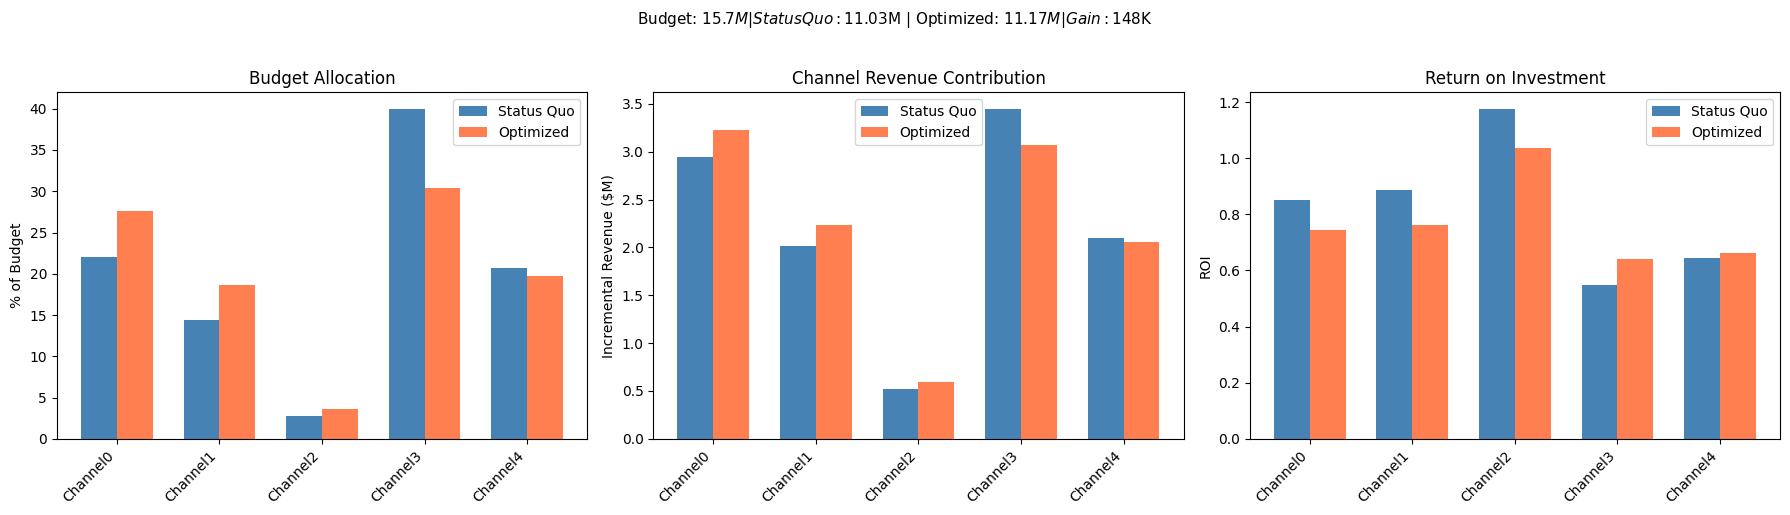

In [ ]:

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

x = np.arange(len(CHANNELS))
w = 0.35

# 1. Budget allocation
sq_pct = nonopt.pct_of_spend.values * 100
op_pct = opt.pct_of_spend.values * 100
axes[0].bar(x - w / 2, sq_pct, w, label="Status Quo", color="steelblue")
axes[0].bar(x + w / 2, op_pct, w, label="Optimized", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(CHANNELS, rotation=45, ha="right")
axes[0].set_ylabel("% of Budget")
axes[0].set_title("Budget Allocation")
axes[0].legend()

# 2. Incremental revenue by channel
sq_rev = nonopt.incremental_outcome.sel(metric="mean").values
op_rev = opt.incremental_outcome.sel(metric="mean").values
axes[1].bar(x - w / 2, sq_rev / 1e6, w, label="Status Quo", color="steelblue")
axes[1].bar(x + w / 2, op_rev / 1e6, w, label="Optimized", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(CHANNELS, rotation=45, ha="right")
axes[1].set_ylabel("Incremental Revenue ($M)")
axes[1].set_title("Channel Revenue Contribution")
axes[1].legend()

# 3. ROI by channel
sq_roi = nonopt.roi.sel(metric="mean").values
op_roi = opt.roi.sel(metric="mean").values
axes[2].bar(x - w / 2, sq_roi, w, label="Status Quo", color="steelblue")
axes[2].bar(x + w / 2, op_roi, w, label="Optimized", color="coral")
axes[2].set_xticks(x)
axes[2].set_xticklabels(CHANNELS, rotation=45, ha="right")
axes[2].set_ylabel("ROI")
axes[2].set_title("Return on Investment")
axes[2].legend()

plt.suptitle(
    f"Budget: ${forecast_config['total_budget']/1e6:.1f}M | "
    f"Status Quo: ${sq_total/1e6:.2f}M | "
    f"Optimized: ${op_total/1e6:.2f}M | "
    f"Gain: ${gain/1e3:.0f}K",
    fontsize=11, y=1.02,
)
plt.tight_layout()
plt.show()



 TREND SUMMARY CHARTS



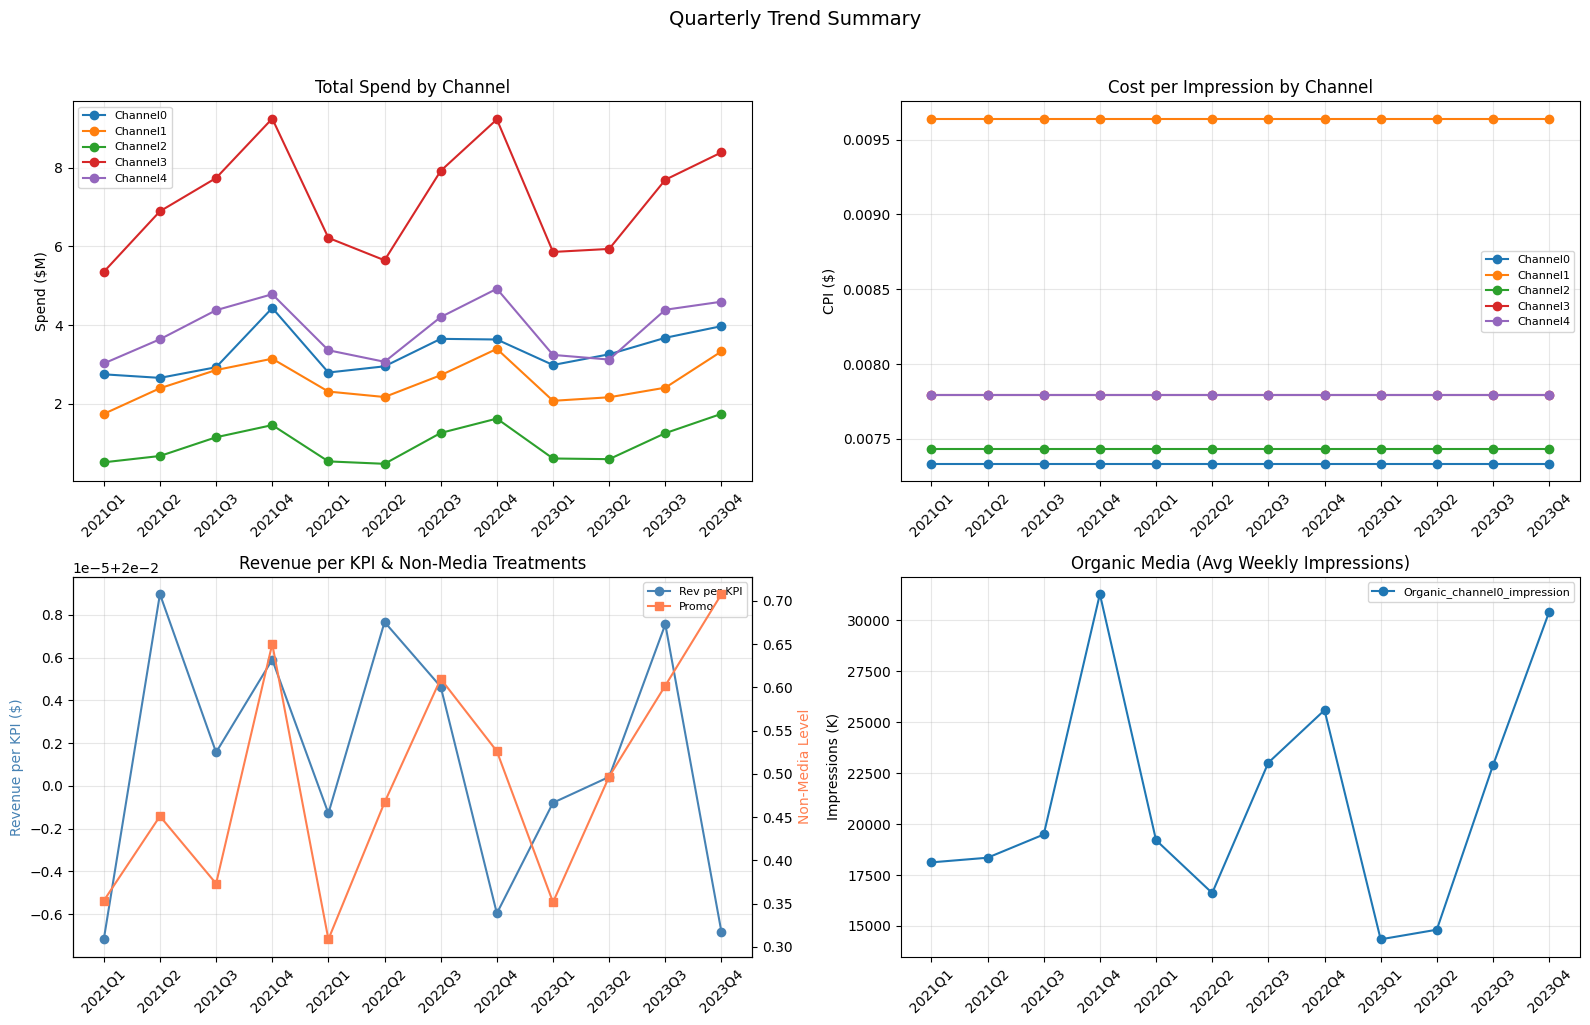

In [ ]:
def plot_trend_summary(quarterly_df, channels, non_media_cols=None, organic_cols=None):
  #Plot quarter-over-quarter trends for all forecasting inputs.
    if non_media_cols is None:
        non_media_cols = []
    if organic_cols is None:
        organic_cols = []

    quarters = quarterly_df["quarter"].values

    # Chart 1: Spend by channel
    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    for ch in channels:
        axes[0, 0].plot(quarters, quarterly_df[f"{ch}_spend"].values / 1e6, marker="o", label=ch)
    axes[0, 0].set_title("Total Spend by Channel")
    axes[0, 0].set_ylabel("Spend ($M)")
    axes[0, 0].legend(fontsize=8)
    axes[0, 0].tick_params(axis="x", rotation=45)
    axes[0, 0].grid(alpha=0.3)

    # Chart 2: Cost per impression by channel
    for ch in channels:
        axes[0, 1].plot(quarters, quarterly_df[f"{ch}_cpi"].values, marker="o", label=ch)
    axes[0, 1].set_title("Cost per Impression by Channel")
    axes[0, 1].set_ylabel("CPI ($)")
    axes[0, 1].legend(fontsize=8)
    axes[0, 1].tick_params(axis="x", rotation=45)
    axes[0, 1].grid(alpha=0.3)

    # Chart 3: Revenue per KPI + non-media
    ax3 = axes[1, 0]
    ax3.plot(quarters, quarterly_df["rev_per_kpi"].values, marker="o", color="steelblue", label="Rev per KPI")
    ax3.set_ylabel("Revenue per KPI ($)", color="steelblue")
    ax3.tick_params(axis="x", rotation=45)
    ax3.grid(alpha=0.3)
    ax3.set_title("Revenue per KPI & Non-Media Treatments")
    if len(non_media_cols) > 0:
        ax3b = ax3.twinx()
        for col in non_media_cols:
            ax3b.plot(quarters, quarterly_df[col].values, marker="s", color="coral", label=col)
        ax3b.set_ylabel("Non-Media Level", color="coral")
        lines1, labels1 = ax3.get_legend_handles_labels()
        lines2, labels2 = ax3b.get_legend_handles_labels()
        ax3.legend(lines1 + lines2, labels1 + labels2, fontsize=8)

    # Chart 4: Organic media
    if len(organic_cols) > 0:
        for col in organic_cols:
            axes[1, 1].plot(quarters, quarterly_df[col].values / 1e3, marker="o", label=col)
        axes[1, 1].set_title("Organic Media (Avg Weekly Impressions)")
        axes[1, 1].set_ylabel("Impressions (K)")
        axes[1, 1].legend(fontsize=8)
    else:
        axes[1, 1].text(0.5, 0.5, "No organic channels", ha="center", va="center")
    axes[1, 1].tick_params(axis="x", rotation=45)
    axes[1, 1].grid(alpha=0.3)

    plt.suptitle("Quarterly Trend Summary", fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()


plot_trend_summary(
    quarterly_df,
    channels=CHANNELS,
    non_media_cols=NON_MEDIA_COLS,
    organic_cols=ORGANIC_COLS,
)


##  SENSITIVITY ANALYSIS



Running sensitivity analysis (this may take a few minutes)...
Baseline period: 2023-01-16 to 2023-04-15 (13 weeks)

=== Forecast Config: Naive vs Trend-Adjusted ===

Total budget:     $    14,072,233 (naive)  ->  $    15,566,465 (adjusted)
Rev per KPI:      $      0.019997 (naive)  ->  $      0.019997 (adjusted)

Channel0 CPI:  $0.007333 (naive)  ->  $0.007333 (adjusted)
Channel1 CPI:  $0.009641 (naive)  ->  $0.009641 (adjusted)
Channel2 CPI:  $0.007431 (naive)  ->  $0.007431 (adjusted)
Channel3 CPI:  $0.007793 (naive)  ->  $0.007793 (adjusted)
Channel4 CPI:  $0.007792 (naive)  ->  $0.007792 (adjusted)

Promo:  0.3485 (naive)  ->  0.3904 (adjusted)
Organic_channel0_impression:  12,436,318 (naive)  ->  13,578,541 (adjusted)
Future DataTensors built: 13 weeks, 5 channels
Date range: 2024-01-22 to 2024-04-15
Total budget: $15,566,465


/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `organic_media` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `non_media_treatments` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(


Baseline period: 2023-01-16 to 2023-04-15 (13 weeks)

=== Forecast Config: Naive vs Trend-Adjusted ===

Total budget:     $    14,072,233 (naive)  ->  $    15,649,477 (adjusted)
Rev per KPI:      $      0.019997 (naive)  ->  $      0.019997 (adjusted)

Channel0 CPI:  $0.007333 (naive)  ->  $0.007333 (adjusted)
Channel1 CPI:  $0.009641 (naive)  ->  $0.009641 (adjusted)
Channel2 CPI:  $0.007431 (naive)  ->  $0.007431 (adjusted)
Channel3 CPI:  $0.007793 (naive)  ->  $0.007793 (adjusted)
Channel4 CPI:  $0.007792 (naive)  ->  $0.007792 (adjusted)

Promo:  0.3485 (naive)  ->  0.3928 (adjusted)
Organic_channel0_impression:  12,436,318 (naive)  ->  13,641,997 (adjusted)
Future DataTensors built: 13 weeks, 5 channels
Date range: 2024-01-22 to 2024-04-15
Total budget: $15,649,477


/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `organic_media` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `non_media_treatments` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(


Baseline period: 2023-01-16 to 2023-04-15 (13 weeks)

=== Forecast Config: Naive vs Trend-Adjusted ===

Total budget:     $    14,072,233 (naive)  ->  $    15,732,490 (adjusted)
Rev per KPI:      $      0.019997 (naive)  ->  $      0.019997 (adjusted)

Channel0 CPI:  $0.007333 (naive)  ->  $0.007333 (adjusted)
Channel1 CPI:  $0.009641 (naive)  ->  $0.009641 (adjusted)
Channel2 CPI:  $0.007431 (naive)  ->  $0.007431 (adjusted)
Channel3 CPI:  $0.007793 (naive)  ->  $0.007793 (adjusted)
Channel4 CPI:  $0.007792 (naive)  ->  $0.007792 (adjusted)

Promo:  0.3485 (naive)  ->  0.3951 (adjusted)
Organic_channel0_impression:  12,436,318 (naive)  ->  13,705,454 (adjusted)
Future DataTensors built: 13 weeks, 5 channels
Date range: 2024-01-22 to 2024-04-15
Total budget: $15,732,490


...

Baseline period: 2023-01-16 to 2023-04-15 (13 weeks)

=== Forecast Config: Naive vs Trend-Adjusted ===

Total budget:     $    14,072,233 (naive)  ->  $    15,981,529 (adjusted)
Rev per KPI:      $      0.019997 (naive)  ->  $      0.019997 (adjusted)

Channel0 CPI:  $0.007333 (naive)  ->  $0.007333 (adjusted)
Channel1 CPI:  $0.009641 (naive)  ->  $0.009641 (adjusted)
Channel2 CPI:  $0.007431 (naive)  ->  $0.007431 (adjusted)
Channel3 CPI:  $0.007793 (naive)  ->  $0.007793 (adjusted)
Channel4 CPI:  $0.007792 (naive)  ->  $0.007792 (adjusted)

Promo:  0.3485 (naive)  ->  0.4021 (adjusted)
Organic_channel0_impression:  12,436,318 (naive)  ->  13,895,825 (adjusted)
Future DataTensors built: 13 weeks, 5 channels
Date range: 2024-01-22 to 2024-04-15
Total budget: $15,981,529


/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `organic_media` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `non_media_treatments` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(


Baseline period: 2023-01-16 to 2023-04-15 (13 weeks)

=== Forecast Config: Naive vs Trend-Adjusted ===

Total budget:     $    14,072,233 (naive)  ->  $    16,064,542 (adjusted)
Rev per KPI:      $      0.019997 (naive)  ->  $      0.019997 (adjusted)

Channel0 CPI:  $0.007333 (naive)  ->  $0.007333 (adjusted)
Channel1 CPI:  $0.009641 (naive)  ->  $0.009641 (adjusted)
Channel2 CPI:  $0.007431 (naive)  ->  $0.007431 (adjusted)
Channel3 CPI:  $0.007793 (naive)  ->  $0.007793 (adjusted)
Channel4 CPI:  $0.007792 (naive)  ->  $0.007792 (adjusted)

Promo:  0.3485 (naive)  ->  0.4044 (adjusted)
Organic_channel0_impression:  12,436,318 (naive)  ->  13,959,281 (adjusted)
Future DataTensors built: 13 weeks, 5 channels
Date range: 2024-01-22 to 2024-04-15
Total budget: $16,064,542


/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `organic_media` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `non_media_treatments` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(



=== Sensitivity Results ===
 growth_multiplier       budget  status_quo_revenue  optimized_revenue     gain
              0.90 1.556646e+07          10976127.0         11125493.0 149366.0
              0.95 1.564948e+07          10999597.0         11148893.0 149296.0
              1.00 1.573249e+07          11026504.0         11174369.0 147865.0
              1.05 1.581550e+07          11048320.0         11197528.0 149208.0
              1.10 1.589852e+07          11075168.0         11223451.0 148283.0
              1.15 1.598153e+07          11098162.0         11246366.0 148204.0
              1.20 1.606454e+07          11126706.0         11274171.0 147465.0


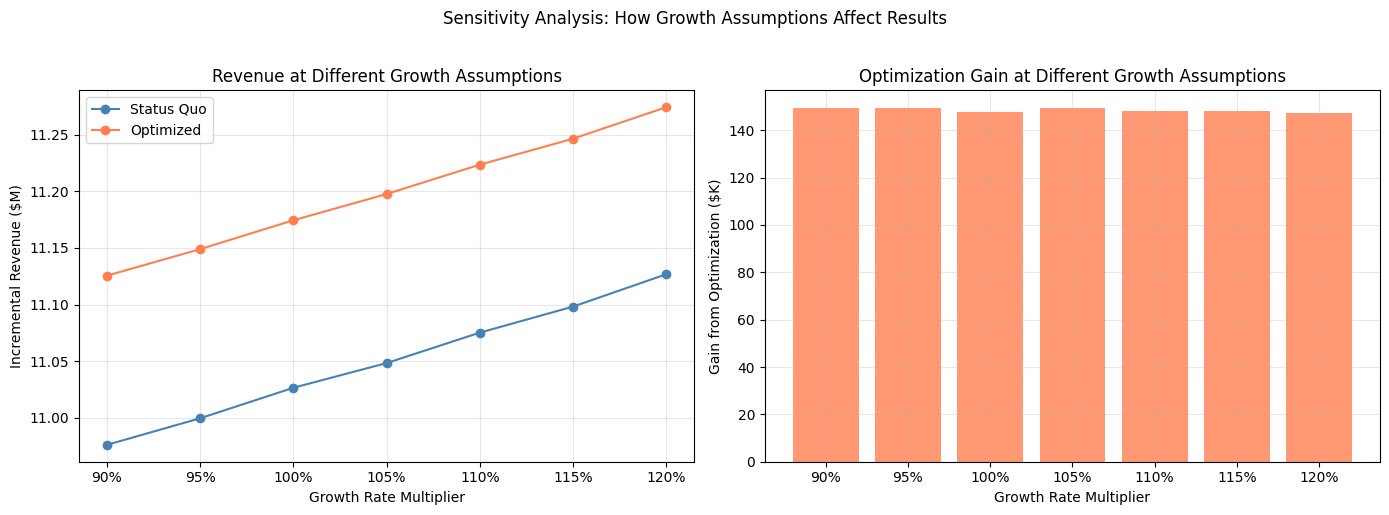

In [ ]:

def run_sensitivity_analysis(
    national_df,
    mmm,
    trend_multipliers,
    channels,
    corresponding_quarter,
    kpi_col,
    rev_per_kpi_col,
    time_col,
    non_media_cols,
    organic_cols,
    impression_suffix,
    spend_suffix,
    n_future_weeks,
    growth_multipliers=None,
):
    # Run optimizer at different growth rate multipliers to show how sensitive the results are to the trend assumption.

    if growth_multipliers is None:
        growth_multipliers = [0.9, 0.95, 1.0, 1.05, 1.1, 1.15, 1.2]

    results = []
    for gm in growth_multipliers:
        # Scale all trend multipliers by the growth multiplier
        adjusted_trends = {k: 1.0 + (v - 1.0) * gm for k, v in trend_multipliers.items()}

        config = build_forecast_config(
            national_df,
            trend_multipliers=adjusted_trends,
            channels=channels,
            corresponding_quarter=corresponding_quarter,
            kpi_col=kpi_col,
            rev_per_kpi_col=rev_per_kpi_col,
            time_col=time_col,
            non_media_cols=non_media_cols,
            organic_cols=organic_cols,
            impression_suffix=impression_suffix,
            spend_suffix=spend_suffix,
            n_future_weeks=n_future_weeks,
        )

        future_data, _ = build_future_data_tensors(
            config,
            channels=channels,
            last_date=national_df[time_col].max(),
            non_media_cols=non_media_cols,
            organic_cols=organic_cols,
        )

        bo = optimizer.BudgetOptimizer(mmm)
        opt_result = bo.optimize(
            new_data=future_data,
            budget=config["total_budget"],
            pct_of_spend=list(config["spend_pct"].values()),
        )

        sq_rev = float(opt_result.nonoptimized_data.attrs["total_incremental_outcome"])
        op_rev = float(opt_result.optimized_data.attrs["total_incremental_outcome"])

        results.append({
            "growth_multiplier": gm,
            "budget": config["total_budget"],
            "status_quo_revenue": sq_rev,
            "optimized_revenue": op_rev,
            "gain": op_rev - sq_rev,
        })

    return pd.DataFrame(results)


print("Running sensitivity analysis (this may take a few minutes)...")
sensitivity_df = run_sensitivity_analysis(
    national_df=national_df,
    mmm=mmm,
    trend_multipliers=trend_multipliers,
    channels=CHANNELS,
    corresponding_quarter=CORRESPONDING_QUARTER,
    kpi_col=KPI_COL,
    rev_per_kpi_col=REV_PER_KPI_COL,
    time_col=TIME_COL,
    non_media_cols=NON_MEDIA_COLS,
    organic_cols=ORGANIC_COLS,
    impression_suffix=IMPRESSION_SUFFIX,
    spend_suffix=SPEND_SUFFIX,
    n_future_weeks=N_FUTURE_WEEKS,
)

print("\n=== Sensitivity Results ===")
print(sensitivity_df.to_string(index=False))

# Plot sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

gm_labels = [f"{g:.0%}" for g in sensitivity_df["growth_multiplier"]]

axes[0].plot(gm_labels, sensitivity_df["status_quo_revenue"] / 1e6, marker="o", label="Status Quo", color="steelblue")
axes[0].plot(gm_labels, sensitivity_df["optimized_revenue"] / 1e6, marker="o", label="Optimized", color="coral")
axes[0].set_xlabel("Growth Rate Multiplier")
axes[0].set_ylabel("Incremental Revenue ($M)")
axes[0].set_title("Revenue at Different Growth Assumptions")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(gm_labels, sensitivity_df["gain"] / 1e3, color="coral", alpha=0.8)
axes[1].set_xlabel("Growth Rate Multiplier")
axes[1].set_ylabel("Gain from Optimization ($K)")
axes[1].set_title("Optimization Gain at Different Growth Assumptions")
axes[1].grid(alpha=0.3)

plt.suptitle("Sensitivity Analysis: How Growth Assumptions Affect Results", fontsize=12, y=1.02)
plt.tight_layout()
plt.show()



## VALIDATION TEST


In [ ]:
def run_backtest(
    df,
    channels,
    kpi_col,
    rev_per_kpi_col,
    time_col,
    non_media_cols,
    organic_cols,
    organic_names,
    impression_suffix,
    spend_suffix,
    backtest_train_end,
    backtest_quarter,
    n_future_weeks,
    roi_mu,
    roi_sigma,
    n_chains,
    n_adapt,
    n_burnin,
    n_keep,
    seed,
    n_prior_samples,
):
    """
    Backtest the full pipeline:
    1. Train Meridian on data up to backtest_train_end
    2. Compute trends from training data
    3. Build forecast config for the backtest quarter
    4. Run optimizer
    5. Compare predicted incremental outcome against actual
    """
    df = df.copy()
    df["time_dt"] = pd.to_datetime(df[time_col])

    # Split: train on everything up to backtest_train_end
    train_df = df[df["time_dt"] <= backtest_train_end].drop(columns=["time_dt"])
    actual_df = df[
        (df["time_dt"] >= backtest_quarter[0]) & (df["time_dt"] <= backtest_quarter[1])
    ].drop(columns=["time_dt"])

    print(f"Backtest train: {len(train_df)} weeks (up to {backtest_train_end})")
    print(f"Backtest target: {len(actual_df)} weeks ({backtest_quarter[0]} to {backtest_quarter[1]})")

    # Rebuild InputData from training data only
    _media_cols = [f"{ch}{impression_suffix}" for ch in channels]
    _spend_cols = [f"{ch}{spend_suffix}" for ch in channels]

    bt_builder = data_frame_input_data_builder.DataFrameInputDataBuilder(
        kpi_type="non_revenue",
        default_kpi_column=kpi_col,
        default_revenue_per_kpi_column=rev_per_kpi_col,
    )
    bt_builder = (
        bt_builder
        .with_kpi(train_df)
        .with_revenue_per_kpi(train_df)
        .with_media(train_df, media_cols=_media_cols, media_spend_cols=_spend_cols, media_channels=channels)
        .with_non_media_treatments(train_df, non_media_treatment_cols=non_media_cols)
        .with_organic_media(train_df, organic_media_cols=organic_cols, organic_media_channels=organic_names)
    )
    bt_data = bt_builder.build()

    # Fit model on training data
    bt_prior = prior_distribution.PriorDistribution(
        roi_m=tfp.distributions.LogNormal(roi_mu, roi_sigma, name=constants.ROI_M)
    )
    bt_spec = spec.ModelSpec(prior=bt_prior)
    bt_mmm = model.Meridian(input_data=bt_data, model_spec=bt_spec)
    bt_mmm.sample_prior(n_prior_samples)

    print("Fitting backtest model...")
    bt_mmm.sample_posterior(
        n_chains=n_chains, n_adapt=n_adapt, n_burnin=n_burnin, n_keep=n_keep, seed=seed
    )

    # Compute trends from training data
    bt_trends, bt_quarterly = compute_trend_multipliers(
        train_df, channels=channels, kpi_col=kpi_col, rev_per_kpi_col=rev_per_kpi_col,
        time_col=time_col, non_media_cols=non_media_cols, organic_cols=organic_cols,
        impression_suffix=impression_suffix, spend_suffix=spend_suffix,
    )

    # Find corresponding quarter from year before the backtest quarter
    bt_start = pd.to_datetime(backtest_quarter[0])
    bt_end = pd.to_datetime(backtest_quarter[1])
    corr_start = (bt_start - pd.DateOffset(years=1)).strftime("%Y-%m-%d")
    corr_end = (bt_end - pd.DateOffset(years=1)).strftime("%Y-%m-%d")

    # Build forecast config
    bt_config = build_forecast_config(
        train_df, trend_multipliers=bt_trends, channels=channels,
        corresponding_quarter=(corr_start, corr_end),
        kpi_col=kpi_col, rev_per_kpi_col=rev_per_kpi_col, time_col=time_col,
        non_media_cols=non_media_cols, organic_cols=organic_cols,
        impression_suffix=impression_suffix, spend_suffix=spend_suffix,
        n_future_weeks=n_future_weeks,
    )

    # Build future DataTensors
    bt_future, bt_dates = build_future_data_tensors(
        bt_config, channels=channels, last_date=train_df[time_col].max(),
        non_media_cols=non_media_cols, organic_cols=organic_cols,
    )

    # Run optimizer
    bt_optimizer = optimizer.BudgetOptimizer(bt_mmm)
    bt_results = bt_optimizer.optimize(
        new_data=bt_future, budget=bt_config["total_budget"],
        pct_of_spend=list(bt_config["spend_pct"].values()),
    )


    predicted_sq = float(bt_results.nonoptimized_data.attrs["total_incremental_outcome"])
    predicted_opt = float(bt_results.optimized_data.attrs["total_incremental_outcome"])

    actual_spend = actual_df[_spend_cols].sum().sum()
    actual_revenue = (actual_df[kpi_col] * actual_df[rev_per_kpi_col]).sum()

    sq_pct = bt_results.nonoptimized_data.pct_of_spend.values * 100
    opt_pct = bt_results.optimized_data.pct_of_spend.values * 100
    actual_alloc = actual_df[_spend_cols].sum()
    actual_pct = (actual_alloc / actual_spend * 100).values

    print(f"\n=== Backtest Results: {backtest_quarter[0]} to {backtest_quarter[1]} ===\n")
    print(f"Actual total spend:         ${actual_spend:>14,.0f}")
    print(f"Predicted budget:           ${bt_config['total_budget']:>14,.0f}")
    print(f"Budget error:               {abs(bt_config['total_budget'] - actual_spend) / actual_spend * 100:.1f}%")
    print(f"Actual total revenue:       ${actual_revenue:>14,.0f}")
    print(f"Predicted incr. (sq):       ${predicted_sq:>14,.0f}")
    print(f"Predicted incr. (opt):      ${predicted_opt:>14,.0f}")
    print()
    print("Allocation comparison:")
    print(f"{'Channel':<12} {'Baseline':>10} {'Actual':>10} {'Predicted':>10} {'Act Dir':>10} {'Pred Dir':>10} {'Match':>8}")
    print("-" * 72)

    correct_directions = 0
    abs_errors = []
    for i, ch in enumerate(channels):
        b = sq_pct[i]          # baseline (status quo from corresponding quarter)
        a = actual_pct[i]      # what actually happened
        p = opt_pct[i]         # what optimizer recommended

        actual_dir = "↑" if a > b + 0.5 else "↓" if a < b - 0.5 else "—"
        pred_dir = "↑" if p > b + 0.5 else "↓" if p < b - 0.5 else "—"
        match = "✓" if actual_dir == pred_dir else "✗"
        if actual_dir == pred_dir:
            correct_directions += 1

        abs_errors.append(abs(p - a))
        print(f"{ch:<12} {b:>9.1f}% {a:>9.1f}% {p:>9.1f}% {actual_dir:>10} {pred_dir:>10} {match:>8}")

    print(f"\nDirectional accuracy: {correct_directions}/{len(channels)}")
    print(f"Mean absolute allocation error: {np.mean(abs_errors):.1f}%")
    print(f"Max allocation error: {np.max(abs_errors):.1f}% ({channels[np.argmax(abs_errors)]})")

    return bt_results, bt_config


print("\n" + "=" * 60)
print("RUNNING BACKTEST — training model on data up to Q3 2023")
print("=" * 60 + "\n")

bt_results, bt_config = run_backtest(
    df=national_df,
    channels=CHANNELS,
    kpi_col=KPI_COL,
    rev_per_kpi_col=REV_PER_KPI_COL,
    time_col=TIME_COL,
    non_media_cols=NON_MEDIA_COLS,
    organic_cols=ORGANIC_COLS,
    organic_names=ORGANIC_NAMES,
    impression_suffix=IMPRESSION_SUFFIX,
    spend_suffix=SPEND_SUFFIX,
    backtest_train_end="2023-09-30",
    backtest_quarter=("2023-10-02", "2024-01-15"),
    n_future_weeks=N_FUTURE_WEEKS,
    roi_mu=ROI_MU,
    roi_sigma=ROI_SIGMA,
    n_chains=N_CHAINS,
    n_adapt=N_ADAPT,
    n_burnin=N_BURNIN,
    n_keep=N_KEEP,
    seed=SEED,
    n_prior_samples=N_PRIOR_SAMPLES,
)


RUNNING BACKTEST — training model on data up to Q3 2023

Backtest train: 140 weeks (up to 2023-09-30)
Backtest target: 16 weeks (2023-10-02 to 2024-01-15)


/usr/local/lib/python3.13/dist-packages/meridian/model/model.py:103: UserWarning: In a nationally aggregated model, the `media_effects_dist` will be reset to `normal`.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/model/prior_distribution.py:1391: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. tau_g_excl_baseline has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/model/prior_distribution.py:1391: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_m has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/model/prior_distribution.py:1391: UserWarning: Hierarchical distribution parameters must be deterministically zero for national models. eta_rf has been automatically set to Deterministic(0).
  warnings.warn(
/usr/local/lib/python3.13/dist-p

Fitting backtest model...


/usr/local/lib/python3.13/dist-packages/arviz/data/inference_data.py:157: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/arviz/data/inference_data.py:1647: UserWarning: trace group is not defined in the InferenceData scheme
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `organic_media` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(
/usr/local/lib/python3.13/dist-packages/meridian/analysis/tensors.py:715: UserWarning: A `non_media_treatments` value was passed in the `new_data` argument. This is not supported and will be ignored.
  warnings.warn(


=== Trend Multipliers (per quarter) ===

Channel0:
  CPI: growing at 0.0%/quarter
  Spend: growing at 5.4%/quarter
Channel1:
  CPI: declining at 0.0%/quarter
  Spend: growing at 6.1%/quarter
Channel2:
  CPI: growing at 0.0%/quarter
  Spend: growing at 29.6%/quarter
Channel3:
  CPI: declining at 0.0%/quarter
  Spend: growing at 7.0%/quarter
Channel4:
  CPI: declining at 0.0%/quarter
  Spend: growing at 6.8%/quarter

Revenue per KPI: growing at 0.0%/quarter
Promo: growing at 13.0%/quarter
Organic_channel0_impression: growing at 7.9%/quarter
Baseline period: 2022-10-02 to 2023-01-15 (15 weeks)

=== Forecast Config: Naive vs Trend-Adjusted ===

Total budget:     $    26,149,387 (naive)  ->  $    29,023,988 (adjusted)
Rev per KPI:      $      0.019996 (naive)  ->  $      0.019998 (adjusted)

Channel0 CPI:  $0.007333 (naive)  ->  $0.007333 (adjusted)
Channel1 CPI:  $0.009641 (naive)  ->  $0.009641 (adjusted)
Channel2 CPI:  $0.007431 (naive)  ->  $0.007431 (adjusted)
Channel3 CPI:  $0.007793 

## SAVE MODEL



In [ ]:
file_path = f"{meridian_root}/saved_mmm.binpb"
meridian_serde.save_meridian(mmm, file_path)
print(f"Model saved at {file_path}")


Model saved at /content/drive/MyDrive//saved_mmm.binpb
